# Do UFOs Only Show Up When It's Cloudy?

Sources:
- Wikipedia — List of reported UFO sightings: https://en.wikipedia.org/wiki/List_of_reported_UFO_sightings
- Open-Meteo Historical Weather API: https://open-meteo.com/en/docs/historical-weather-api

**Part 1. Data Collection: Web Scraping**

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.robotparser import RobotFileParser
import numpy as np

h = {"User-Agent": "Mozilla/5.0 (KBTU student project)"}
u = "https://en.wikipedia.org/wiki/List_of_reported_UFO_sightings"

In [ ]:
r = requests.get("https://en.wikipedia.org/robots.txt", headers=h)
print(r.status_code)
rp = RobotFileParser()
rp.parse(r.text.splitlines())
print("can fetch:", rp.can_fetch("*", u))

200
can fetch: True


In [ ]:
r = requests.get(u, headers=h)
print(r.status_code)
s = BeautifulSoup(r.text, "html.parser")
print(s.title.text)

200
List of reported UFO sightings - Wikipedia


In [ ]:
t = s.find_all("table", class_="wikitable")
print(len(t))
print([th.get_text(strip=True) for th in t[0].find_all("th")])

7
['Date', 'Name', 'Location', 'Description']


In [ ]:
rows = []
for x in t:
    p = x.find_previous(["h2", "h3"])
    p = p.get_text(strip=True) if p else None
    for tr in x.find_all("tr")[1:]:
        td = tr.find_all("td")
        if len(td) < 4:
            continue
        for sup in tr.find_all("sup"):
            sup.decompose()
        rows.append([c.get_text(" ", strip=True) for c in td[:4]] + [p])
print(len(rows))

137


In [ ]:
df = pd.DataFrame(rows, columns=["date", "name", "location", "description", "period"])
print(df.shape)
df.head()

(137, 5)


,date,name,location,description,period
0,c. 1450 BC,Thutmose III Jebel Barkal Stele,"Africa Ancient Egypt ; Jebel Barkal , Lower Egypt","After a military campaign in Nubia , Thutmose ...",Antiquity
1,218 BC,Ships in the sky,Europe Roman Republic ; Italia,"Some 200 years after the event, Livy recorded ...",Antiquity
2,76 BC,Spark from a falling star,Asia Roman Republic ; Asia,"According to Pliny the Elder , a spark fell fr...",Antiquity
3,73 BC,Flame-like wine-jars from the sky,"Asia Roman Republic ; Phrygia , Asia","According to Plutarch , a Roman army commanded...",Antiquity
4,65 BC,Fiery shield,Europe Roman Republic ; Italia,"In the Naturalis historia (II, 100), Pliny the...",Antiquity


In [ ]:
df.tail()

,date,name,location,description,period
132,February or March 2024 (specific date unknown),Ukrainian military wedge-shaped UAP formation,Europe Ukraine ; Ukrainian war zone,Ukrainian military researchers described a for...,21st century
133,2024- 03-26,Ukrainian military spherical UAP formation,Europe Ukraine ; Ukrainian war zone,Ukrainian military researchers described a for...,21st century
134,2024- 03-28,Ukrainian military in-line spherical UAP forma...,Europe Ukraine ; Ukrainian war zone,Ukrainian military researchers described an in...,21st century
135,2025- 09-09,Yemen orb missile engagement video,"Middle East Yemen, off the coast","At a House Oversight hearing, a congressman pl...",21st century
136,2026-05-31,Campo Largo case,"Brazil ; Campo Largo , Paraná",A digital influencer released videos and repor...,21st century


In [ ]:
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         137 non-null    object
 1   name         137 non-null    object
 2   location     137 non-null    object
 3   description  137 non-null    object
 4   period       137 non-null    object
dtypes: object(5)
memory usage: 5.5+ KB
date           0
name           0
location       0
description    0
period         0
dtype: int64


In [ ]:
df['period'].value_counts()

,count
period,
1950–1974,45
1975–1999,27
21st century,26
1900–1949,23
Antiquity,9
8th–17th centuries,4
19th century,3


In [ ]:
f = df['date'].str.match(r'^\d{4}-\d{2}-\d{1,2}')
print("full date:", f.sum())
print("not full date:", (~f).sum())
df[~f][['date', 'name']].head(10)

full date: 5
not full date: 132


,date,name
0,c. 1450 BC,Thutmose III Jebel Barkal Stele
1,218 BC,Ships in the sky
2,76 BC,Spark from a falling star
3,73 BC,Flame-like wine-jars from the sky
4,65 BC,Fiery shield
5,AD 64,Flying shield
6,AD 65,Burning shields
7,AD 65,Sky army
8,AD 196,Angel hair
9,AD c. 740,Air ship of Clonmacnoise


In [ ]:
df.to_csv("ufo_raw.csv", index=False)
print("saved:", df.shape)

saved: (137, 5)


**Part 2. Data Collection: API**

API: Open-Meteo — [Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) and [Geocoding API](https://open-meteo.com/en/docs/geocoding-api). Free, no API key needed.

Input: `ufo_raw.csv` from Part 1. For every sighting we get the weather (cloud cover, precipitation, temperature) on that day and place.

In [ ]:
import requests
import pandas as pd
import time

df = pd.read_csv("ufo_raw.csv")
df["id"] = df.index
print(df.shape)

(137, 6)


**Step 1. Exact dates**

The weather API needs an exact day, and its data starts in 1940. Dates look like `1947- 07-08` (with a space) or ranges like `1952- 07-12 to 1952- 07-29`, so we remove spaces and take the first `YYYY-MM-DD`. Rows like `c. 1947` or `218 BC` have no exact day.

In [ ]:
d = df["date"].str.replace(" ", "").str.extract(r"^(\d{4}-\d{2}-\d{1,2})")[0]
df["d"] = pd.to_datetime(d, format="%Y-%m-%d", errors="coerce")
print("exact date:", df["d"].notna().sum())

w = df[df["d"].dt.year >= 1940].copy()
print("exact date from 1940:", len(w))

exact date: 108
exact date from 1940: 103


**Step 2. Split the location**

Location looks like `North America United States ; Roswell, New Mexico`: continent, country, then `;`, then town and region. We remove the continent, take the country, and split the rest by commas. Words like `near` / `north of` are removed, so `a farm near McMinnville` becomes `McMinnville`.

In [ ]:
cont = ["North America", "South America", "Europe", "Asia", "Africa", "Oceania", "Middle East"]

def split_loc(x):
    for k in cont:
        x = x.replace(k, "")
    c, p = x.split(";", 1) if ";" in x else ("", x)
    c = c.strip()
    if c == "Soviet Union":
        c = "Russia"
    places = []
    for q in p.split(","):
        for k in ["near ", "Near ", " of "]:
            q = q.split(k)[-1]
        if q.strip():
            places.append(q.strip())
    return c, places

w["country"], w["places"] = zip(*w["location"].map(split_loc))
w[["location", "country", "places"]].head(10)

,location,country,places
23,"North America United States ; Los Angeles, Cal...",United States,"[Los Angeles, California]"
26,"Europe Sweden ; Ängelholm , Kristianstads County",Sweden,"[Ängelholm, Kristianstads County]"
27,North America United States ; North of Mount R...,United States,"[Mount Rainier, Washington]"
29,North America United States ; En route from Bo...,United States,"[En route from Boise, Idaho to Pendleton, Oregon]"
30,"North America United States ; Phoenix, Arizona",United States,"[Phoenix, Arizona]"
31,North America United States ; about 30 mi. nor...,United States,"[Roswell, New Mexico]"
32,North America United States ; Puget Sound near...,United States,"[Maury Island, Washington]"
34,North America United States ; Kentucky,United States,[Kentucky]
35,North America United States ; New Mexico,United States,[New Mexico]
36,"North America United States ; Montgomery, Alabama",United States,"[Montgomery, Alabama]"


**Step 3. Coordinates (Geocoding API)**

The weather API needs latitude and longitude. We search the first place (the town) and take a result that:
- is a town or city (`feature_code` starts with `PPL`),
- has the same name and is in the same country,
- is in the same region/state, if the region is given.

The US has many towns with the same name (Exeter is in California and in New Hampshire), so for the US the state must match. Rows with only a state or a region (`Kentucky`, `East Anglia`, `Ukrainian war zone`) are too big to have one weather value, so they are skipped.

In [ ]:
g = "https://geocoding-api.open-meteo.com/v1/search"

def geocode(c, places):
    if len(places) == 0:
        return None, None, None
    q, rest = places[0], places[1:]
    r = requests.get(g, params={"name": q, "count": 10})
    found = []
    for x in r.json().get("results", []):
        xc = x.get("country", "")
        if not x.get("feature_code", "").startswith("PPL"):
            continue
        if x["name"] not in q and q not in x["name"]:
            continue
        if c != "" and (xc == "" or (c not in xc and xc not in c)):
            continue
        found.append(x)
    for x in found:
        adm = [x["name"], x.get("admin1", ""), x.get("admin2", ""), x.get("country", "")]
        if any(p in a for p in rest for a in adm):
            return x["name"], x["latitude"], x["longitude"]
    if found and c != "" and c != "United States":
        x = found[0]
        return x["name"], x["latitude"], x["longitude"]
    return None, None, None

print(geocode("United States", ["Exeter", "New Hampshire"]))

('Exeter', 42.98148, -70.94783)


In [ ]:
res = []
for c, p in zip(w["country"], w["places"]):
    res.append(geocode(c, p))
    time.sleep(0.2)

w["place"], w["lat"], w["lon"] = zip(*res)
print("found:", w["lat"].notna().sum())
print("not found:", w["lat"].isna().sum())
w[w["lat"].isna()]["location"].head(10)

found: 58
not found: 45


,location
27,North America United States ; North of Mount R...
29,North America United States ; En route from Bo...
32,North America United States ; Puget Sound near...
34,North America United States ; Kentucky
35,North America United States ; New Mexico
37,North America United States ; North Dakota
38,North America United States ; Mount Palomar ob...
44,Asia Korea ; Wonsan and Sunchon
49,Europe Italy ; Stadio Artemio Franchi in Florence
51,"Europe United Kingdom ; Suffolk , England"


In [ ]:
w = w[w["lat"].notna()]
w[["date", "location", "place", "lat", "lon"]].head(10)

,date,location,place,lat,lon
23,1942- 02-24,"North America United States ; Los Angeles, Cal...",Los Angeles,34.05223,-118.24368
26,1946- 05-18,"Europe Sweden ; Ängelholm , Kristianstads County",Ängelholm,56.24280,12.86219
30,1947- 07-07,"North America United States ; Phoenix, Arizona",Phoenix,33.44838,-112.07404
31,1947- 07-08,North America United States ; about 30 mi. nor...,Roswell,33.39437,-104.52491
36,1948- 07-24,"North America United States ; Montgomery, Alabama",Montgomery,32.36681,-86.29997
39,1950-03-15 to 1950-03-18,"Farmington, New Mexico",Farmington,36.72806,-108.21869
40,1950- 05-11,North America United States ; a farm near McMi...,McMinnville,45.21012,-123.19872
41,1950- 08-15,"North America United States ; Great Falls, Mon...",Great Falls,47.50024,-111.30081
42,1951- 01-20,"North America United States ; Sioux City, Iowa",Sioux City,42.49999,-96.40031
43,1951- 08-25,"North America United States ; Lubbock, Texas",Lubbock,33.57786,-101.85517


**Step 4. Weather (Historical Weather API)**

One request example — Roswell, 1947-07-08. We ask for 31 days (15 days before and after the sighting), so later we can compare the sighting day with the normal weather in that place at that time of year.

Daily variables: `cloud_cover_mean` (%), `precipitation_sum` (mm), `temperature_2m_mean` (°C).

In [ ]:
a = "https://archive-api.open-meteo.com/v1/archive"
v = "cloud_cover_mean,precipitation_sum,temperature_2m_mean"

r = requests.get(a, params={"latitude": 33.39, "longitude": -104.52, "start_date": "1947-06-23",
                            "end_date": "1947-07-23", "daily": v, "timezone": "auto"})
print(r.status_code)
j = r.json()
print(j["daily_units"])
pd.DataFrame(j["daily"]).head()

200
{'time': 'iso8601', 'cloud_cover_mean': '%', 'precipitation_sum': 'mm', 'temperature_2m_mean': '°C'}


,time,cloud_cover_mean,precipitation_sum,temperature_2m_mean
0,1947-06-23,3,0.0,25.9
1,1947-06-24,57,6.0,24.7
2,1947-06-25,6,0.0,26.7
3,1947-06-26,24,0.0,30.0
4,1947-06-27,31,0.0,30.9


In [ ]:
out = []
codes = []
for _, x in w.iterrows():
    s = (x["d"] - pd.Timedelta(days=15)).strftime("%Y-%m-%d")
    e = (x["d"] + pd.Timedelta(days=15)).strftime("%Y-%m-%d")
    r = requests.get(a, params={"latitude": x["lat"], "longitude": x["lon"], "start_date": s,
                                "end_date": e, "daily": v, "timezone": "auto"})
    codes.append(r.status_code)
    t = pd.DataFrame(r.json()["daily"])
    day = t[t["time"] == x["d"].strftime("%Y-%m-%d")].iloc[0]
    out.append({
        "id": x["id"],
        "date": x["d"].strftime("%Y-%m-%d"),
        "place": x["place"],
        "lat": x["lat"],
        "lon": x["lon"],
        "cloud_cover": day["cloud_cover_mean"],
        "precipitation": day["precipitation_sum"],
        "temperature": day["temperature_2m_mean"],
        "cloud_cover_avg": round(t["cloud_cover_mean"].mean(), 1),
        "precipitation_avg": round(t["precipitation_sum"].mean(), 2)
    })
    time.sleep(0.5)

print(pd.Series(codes).value_counts())
print(len(out))

200    58
Name: count, dtype: int64
58


`cloud_cover`, `precipitation`, `temperature` — weather on the sighting day.
`cloud_cover_avg`, `precipitation_avg` — average over the 31 days around it (normal weather for that place and season).

In [ ]:
wd = pd.DataFrame(out)
print(wd.shape)
wd.head(10)

(58, 10)


,id,date,place,lat,lon,cloud_cover,precipitation,temperature,cloud_cover_avg,precipitation_avg
0,23,1942-02-24,Los Angeles,34.05223,-118.24368,24,0.0,8.8,40.0,0.60
1,26,1946-05-18,Ängelholm,56.24280,12.86219,91,4.3,11.6,51.2,1.24
2,30,1947-07-07,Phoenix,33.44838,-112.07404,1,0.0,34.4,17.8,0.03
3,31,1947-07-08,Roswell,33.39437,-104.52491,4,0.0,29.7,25.8,1.13
4,36,1948-07-24,Montgomery,32.36681,-86.29997,34,2.9,27.5,60.4,5.08
5,39,1950-03-15,Farmington,36.72806,-108.21869,38,0.0,4.5,43.8,0.53
6,40,1950-05-11,McMinnville,45.21012,-123.19872,13,0.0,15.6,58.8,1.53
7,41,1950-08-15,Great Falls,47.50024,-111.30081,41,0.1,21.6,43.0,0.91
8,42,1951-01-20,Sioux City,42.49999,-96.40031,100,4.4,-10.2,54.3,0.23
9,43,1951-08-25,Lubbock,33.57786,-101.85517,44,0.0,25.7,31.0,1.99


In [ ]:
print(wd.dtypes)
print(wd.isna().sum())

id                     int64
date                  object
place                 object
lat                  float64
lon                  float64
cloud_cover            int64
precipitation        float64
temperature          float64
cloud_cover_avg      float64
precipitation_avg    float64
dtype: object
id                   0
date                 0
place                0
lat                  0
lon                  0
cloud_cover          0
precipitation        0
temperature          0
cloud_cover_avg      0
precipitation_avg    0
dtype: int64


`id` is the row number in `ufo_raw.csv`, so in Part 3 the weather can be joined back to the sightings by `id`.

In [ ]:
wd.to_csv("weather_data.csv", index=False)
print("saved:", wd.shape)

saved: (58, 10)


**Part 3. Data cleaning**

Here, ufo is our static web page (https://en.wikipedia.org/wiki/List_of_reported_UFO_sightings)

and w is our API (https://open-meteo.com/en/docs/historical-weather-api)

In [ ]:
ufo = pd.read_csv("ufo_raw.csv")
w = pd.read_csv("weather_data.csv")


we will need id column for further task with merge

In [ ]:
ufo = ufo.reset_index(drop=True)
ufo["id"] = ufo.index



*   For each column name we change to lower case and replace space with _
*   for each of 5 columns we change column type to str (replaces missing values to nan), for any number of consecutive spaces, tabs we replace them to one space


*   As we did it previously with data cleaning, we are doing the same procedures and save them in ufo
*   Checking





In [ ]:
ufo.columns = [c.strip().lower().replace(" ", "_") for c in ufo.columns]
w.columns = [c.strip().lower().replace(" ", "_") for c in w.columns]

for c in ["name", "location", "description", "period", "date"]:
    ufo[c] = ufo[c].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

ufo["date"] = ufo["date"].str.replace(r"\s+", "", regex=True)

print(ufo[["date", "name", "location"]].head())
print("dtypes:\n", ufo.dtypes)

       date                               name  \
0  c.1450BC    Thutmose III Jebel Barkal Stele   
1     218BC                   Ships in the sky   
2      76BC          Spark from a falling star   
3      73BC  Flame-like wine-jars from the sky   
4      65BC                       Fiery shield   

                                            location  
0  Africa Ancient Egypt ; Jebel Barkal , Lower Egypt  
1                     Europe Roman Republic ; Italia  
2                         Asia Roman Republic ; Asia  
3               Asia Roman Republic ; Phrygia , Asia  
4                     Europe Roman Republic ; Italia  
dtypes:
 date           object
name           object
location       object
description    object
period         object
id              int64
dtype: object


Here, we are looking for nan, duplicates and empty strings and clean them if needed

we have 0 missing values and 0 duplicates

In [ ]:
ufo = ufo.replace({"": np.nan, "nan": np.nan})

print("Missing values before:\n", ufo.isna().sum())

before = len(ufo)
ufo = ufo.drop_duplicates(subset=["name", "date"], keep="first").reset_index(drop=True)
print(f"Duplicates removed: {before - len(ufo)}")

print("UFO after cleaning:", ufo.shape)
print(ufo.isna().sum())

Missing values before:
 date           0
name           0
location       0
description    0
period         0
id             0
dtype: int64
Duplicates removed: 0
UFO after cleaning: (137, 6)
date           0
name           0
location       0
description    0
period         0
id             0
dtype: int64




*   Here we are converting strings to datetime (or NaT)
*   in a loop we are converting all numeric columns from strings to numbers


*   we count missing values
*   delete rows where we don't have date, cloudiness or temperature


*   recounting shape







In [ ]:
w["date"] = pd.to_datetime(w["date"], errors="coerce")
for c in ["cloud_cover", "precipitation", "temperature",
          "cloud_cover_avg", "precipitation_avg", "lat", "lon"]:
        w[c] = pd.to_numeric(w[c], errors="coerce")

print("Missing values in weather before:\n", w.isna().sum())
w = w.dropna(subset=["date", "cloud_cover", "temperature"]).reset_index(drop=True)
print("weather after cleaning:", w.shape)

Missing values in weather before:
 id                   0
date                 0
place                0
lat                  0
lon                  0
cloud_cover          0
precipitation        0
temperature          0
cloud_cover_avg      0
precipitation_avg    0
dtype: int64
weather after cleaning: (58, 10)


In [ ]:
print("=== UFO ===");   print(ufo.dtypes); print(ufo.shape)
print("\n=== WEATHER ==="); print(w.dtypes); print(w.shape)

=== UFO ===
date           object
name           object
location       object
description    object
period         object
id              int64
dtype: object
(137, 6)

=== WEATHER ===
id                            int64
date                 datetime64[ns]
place                        object
lat                         float64
lon                         float64
cloud_cover                   int64
precipitation               float64
temperature                 float64
cloud_cover_avg             float64
precipitation_avg           float64
dtype: object
(58, 10)


**Part 4. Merging**

In [ ]:
ufo = ufo.copy()
ufo["date_norm"] = pd.to_datetime(ufo["date"], errors="coerce").dt.strftime("%Y-%m-%d")

w = w.copy()
w["date_norm"] = pd.to_datetime(w["date"], errors="coerce").dt.strftime("%Y-%m-%d")

ufo["place_key"]  = ufo["location"].str.extract(r";\s*([^,;]+)")[0].str.strip().str.lower()
w["place_key"]    = w["place"].astype(str).str.strip().str.lower()

merged = ufo.merge(
    w[["date_norm", "place_key", "cloud_cover", "precipitation", "temperature",
       "cloud_cover_avg", "precipitation_avg", "lat", "lon", "place"]],
    on=["date_norm", "place_key"],
    how="left",
    suffixes=("", "_weather")
)

print("after merge (date + place):", merged.shape)
print("rows without weather:", merged["cloud_cover"].isna().sum())
merged.head()

after merge (date + place): (137, 16)
rows without weather: 92


/tmp/ipykernel_2145/1636771225.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ufo["date_norm"] = pd.to_datetime(ufo["date"], errors="coerce").dt.strftime("%Y-%m-%d")


,date,name,location,description,period,id,date_norm,place_key,cloud_cover,precipitation,temperature,cloud_cover_avg,precipitation_avg,lat,lon,place
0,c.1450BC,Thutmose III Jebel Barkal Stele,"Africa Ancient Egypt ; Jebel Barkal , Lower Egypt","After a military campaign in Nubia , Thutmose ...",Antiquity,0,NaN,jebel barkal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,218BC,Ships in the sky,Europe Roman Republic ; Italia,"Some 200 years after the event, Livy recorded ...",Antiquity,1,NaN,italia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,76BC,Spark from a falling star,Asia Roman Republic ; Asia,"According to Pliny the Elder , a spark fell fr...",Antiquity,2,NaN,asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,73BC,Flame-like wine-jars from the sky,"Asia Roman Republic ; Phrygia , Asia","According to Plutarch , a Roman army commanded...",Antiquity,3,NaN,phrygia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65BC,Fiery shield,Europe Roman Republic ; Italia,"In the Naturalis historia (II, 100), Pliny the...",Antiquity,4,NaN,italia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = merged
df["has_weather"]       = df["cloud_cover"].notna()
df["cloudy"]            = df["cloud_cover"] >= 50
df["cloudier_than_avg"] = df["cloud_cover"] > df["cloud_cover_avg"]
df["rainy"]             = df["precipitation"] > 0
df["year"]              = pd.to_datetime(df["date"], errors="coerce").dt.year

df[["date", "location", "cloud_cover", "cloud_cover_avg",
    "cloudy", "cloudier_than_avg", "year"]].head()

/tmp/ipykernel_2145/2059063241.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["year"]              = pd.to_datetime(df["date"], errors="coerce").dt.year


,date,location,cloud_cover,cloud_cover_avg,cloudy,cloudier_than_avg,year
0,c.1450BC,"Africa Ancient Egypt ; Jebel Barkal , Lower Egypt",NaN,NaN,False,False,NaN
1,218BC,Europe Roman Republic ; Italia,NaN,NaN,False,False,NaN
2,76BC,Asia Roman Republic ; Asia,NaN,NaN,False,False,NaN
3,73BC,"Asia Roman Republic ; Phrygia , Asia",NaN,NaN,False,False,NaN
4,65BC,Europe Roman Republic ; Italia,NaN,NaN,False,False,NaN


In [ ]:
daily = (df.groupby("date")
           .agg(sightings=("id", "count"),
                avg_cloud=("cloud_cover", "mean"),
                avg_temp=("temperature", "mean"))
           .reset_index())

df = df.merge(daily, on="date", how="left")

print(df[["date", "sightings", "avg_cloud", "avg_temp"]].head())
print("final shape:", df.shape)

       date  sightings  avg_cloud  avg_temp
0  c.1450BC          1        NaN       NaN
1     218BC          1        NaN       NaN
2      76BC          1        NaN       NaN
3      73BC          1        NaN       NaN
4      65BC          1        NaN       NaN
final shape: (137, 24)


In [ ]:
print("Final dataframe:", df.shape)
print("gaps in main columns:\n",
      df[["cloud_cover", "temperature", "sightings"]].isna().sum())

print("\nCloudiness (describe):")
print(df["cloud_cover"].describe())

print("\nProportion of cloudy days (>=50%):", round(df["cloudy"].mean(), 3))

df.to_csv("ufo_clean.csv", index=False)
print("\nsaved: ufo_clean.csv", df.shape)

Final dataframe: (137, 24)
gaps in main columns:
 cloud_cover    92
temperature    92
sightings       0
dtype: int64

Cloudiness (describe):
count     45.000000
mean      47.733333
std       33.627910
min        0.000000
25%       17.000000
50%       44.000000
75%       79.000000
max      100.000000
Name: cloud_cover, dtype: float64

Proportion of cloudy days (>=50%): 0.153

saved: ufo_clean.csv (137, 24)


**Part 5. Analysis and Visualization**

**Step 1. Load data**

We load `ufo_clean.csv` and keep only the rows where weather was found.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("ufo_clean.csv")
data = df[df["cloud_cover"].notna()].copy()

print("all events:", df.shape)
print("events with weather:", data.shape)

all events: (137, 24)
events with weather: (45, 24)


**Step 2. New columns**

We add year, decade and the difference between the sighting day and the normal cloud cover. We also mark cloudy days (cloud cover 50% or more), rainy days and days cloudier than normal.

In [ ]:
data["year"] = pd.to_datetime(data["date_norm"], errors="coerce").dt.year
data["decade"] = data["year"] // 10 * 10
data["cloud_diff"] = data["cloud_cover"] - data["cloud_cover_avg"]
data["cloudy"] = data["cloud_cover"] >= 50
data["rainy"] = data["precipitation"] > 0
data["cloudier"] = data["cloud_cover"] > data["cloud_cover_avg"]

data.head()

,date,name,location,description,period,id,date_norm,place_key,cloud_cover,precipitation,...,cloudy,cloudier_than_avg,rainy,year,sightings,avg_cloud,avg_temp,decade,cloud_diff,cloudier
23,1942-02-24,Battle of Los Angeles,"North America United States ; Los Angeles, Cal...",Just months after the Japanese attack on Pearl...,1900–1949,23,1942-02-24,los angeles,24.0,0.0,...,False,False,False,1942,1,24.0,8.8,1940,-16.0,False
26,1946-05-18,Ängelholm UFO memorial,"Europe Sweden ; Ängelholm , Kristianstads County","Swedish entrepreneur Gösta Carlsson, attribute...",1900–1949,26,1946-05-18,ängelholm,91.0,4.3,...,True,True,True,1946,1,91.0,11.6,1940,39.8,True
30,1947-07-07,Rhodes UFO photographs,"North America United States ; Phoenix, Arizona",Inventor and amateur astronomer William Albert...,1900–1949,30,1947-07-07,phoenix,1.0,0.0,...,False,False,False,1947,1,1.0,34.4,1940,-16.8,False
36,1948-07-24,Chiles-Whitted UFO encounter,"North America United States ; Montgomery, Alabama","Clarence Chiles and John Whitted, American com...",1900–1949,36,1948-07-24,montgomery,34.0,2.9,...,False,False,True,1948,1,34.0,27.5,1940,-26.4,False
41,1950-08-15,Mariana UFO incident,"North America United States ; Great Falls, Mon...",The manager of Great Falls' pro baseball team ...,1950–1974,41,1950-08-15,great falls,41.0,0.1,...,False,False,True,1950,1,41.0,21.6,1950,-2.0,False


**Step 3. Descriptive statistics**

We calculate `describe()` for the weather columns and the share of cloudy days, rainy days and days cloudier than normal.

In [ ]:
cols = ["cloud_cover", "cloud_cover_avg", "precipitation", "precipitation_avg", "temperature"]

print(data[cols].describe().round(1))
print()
print("share of cloudy days:", round(data["cloudy"].mean(), 2))
print("share of rainy days:", round(data["rainy"].mean(), 2))
print("share of days cloudier than normal:", round(data["cloudier"].mean(), 2))

       cloud_cover  cloud_cover_avg  precipitation  precipitation_avg  \
count         45.0             45.0           45.0               45.0   
mean          47.7             50.9            1.2                2.2   
std           33.6             20.9            2.3                2.2   
min            0.0              7.5            0.0                0.0   
25%           17.0             36.3            0.0                0.6   
50%           44.0             54.3            0.0                2.0   
75%           79.0             66.8            0.7                2.7   
max          100.0             86.4            8.5               12.9   

       temperature  
count         45.0  
mean          14.0  
std            9.9  
min          -10.2  
25%            7.2  
50%           14.3  
75%           22.6  
max           34.4  

share of cloudy days: 0.47
share of rainy days: 0.4
share of days cloudier than normal: 0.47


**Step 4. Correlations**

We check how the weather columns are related to each other.

In [ ]:
data[cols + ["cloud_diff"]].corr().round(2)

,cloud_cover,cloud_cover_avg,precipitation,precipitation_avg,temperature,cloud_diff
cloud_cover,1.00,0.59,0.47,0.27,-0.35,0.78
cloud_cover_avg,0.59,1.00,0.35,0.66,-0.42,-0.04
precipitation,0.47,0.35,1.00,0.27,-0.15,0.32
precipitation_avg,0.27,0.66,0.27,1.00,0.03,-0.17
temperature,-0.35,-0.42,-0.15,0.03,1.00,-0.11
cloud_diff,0.78,-0.04,0.32,-0.17,-0.11,1.00


**Step 5. Groupby by decade**

We calculate the average cloud cover on the sighting day and the normal cloud cover for each decade, and count the events in each decade.

In [ ]:
print(data.groupby("decade")[["cloud_cover", "cloud_cover_avg"]].mean().round(1))
print()
print(data["decade"].value_counts().sort_index())

        cloud_cover  cloud_cover_avg
decade                              
1940           37.5             42.4
1950           47.2             47.6
1960           46.5             50.4
1970           40.6             53.6
1980           55.0             54.4
1990           35.7             37.1
2000           62.8             55.9
2010           76.0             86.4
2020           91.0             74.5

decade
1940     4
1950     9
1960    12
1970     8
1980     3
1990     3
2000     4
2010     1
2020     1
Name: count, dtype: int64


**Step 6. Statistical test**

Main question: is the sighting day cloudier than the normal weather in the same place and season? Both values are for the same event, so we use paired tests: t-test and Wilcoxon test. If the p-value is below 0.05, the difference is significant.

In [ ]:
print("average on sighting day:", round(data["cloud_cover"].mean(), 1))
print("average normal:", round(data["cloud_cover_avg"].mean(), 1))

t_test = stats.ttest_rel(data["cloud_cover"], data["cloud_cover_avg"])
wilcoxon = stats.wilcoxon(data["cloud_cover"], data["cloud_cover_avg"])

print("t-test p-value:", round(t_test.pvalue, 3))
print("Wilcoxon p-value:", round(wilcoxon.pvalue, 3))

average on sighting day: 47.7
average normal: 50.9
t-test p-value: 0.436
Wilcoxon p-value: 0.531


**Plot 1. Histogram: cloud cover on the sighting day**

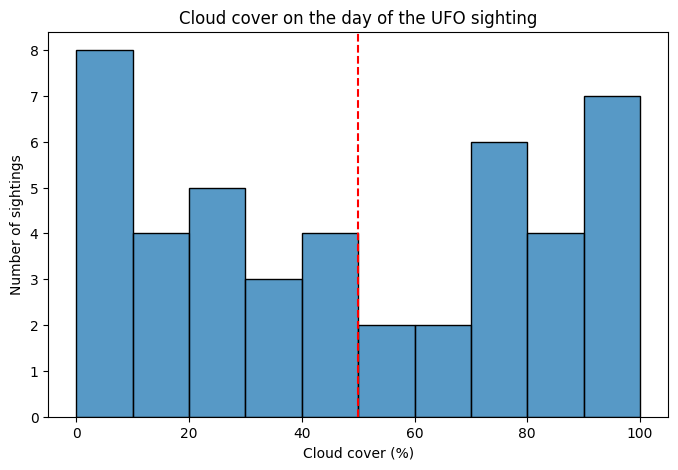

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data["cloud_cover"], bins=10)
plt.axvline(50, color="red", linestyle="--")
plt.title("Cloud cover on the day of the UFO sighting")
plt.xlabel("Cloud cover (%)")
plt.ylabel("Number of sightings")
plt.savefig("plot1_hist.png", dpi=150)
plt.show()

**Plot 2. Scatter: sighting day vs normal cloud cover**

Points above the dashed line are cloudier than normal.

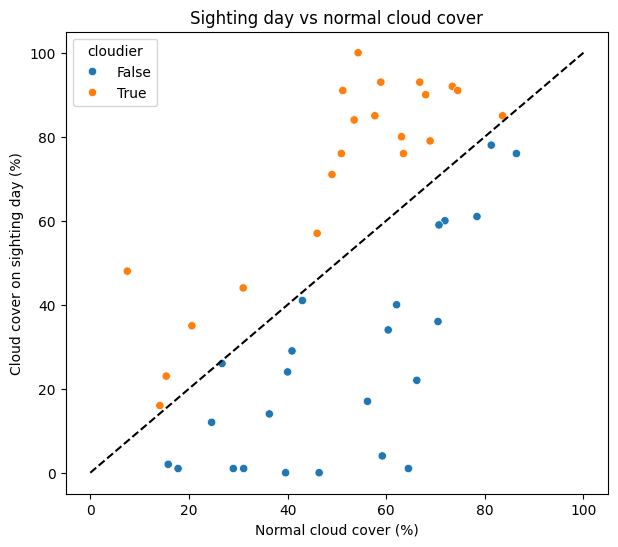

In [ ]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=data, x="cloud_cover_avg", y="cloud_cover", hue="cloudier")
plt.plot([0, 100], [0, 100], color="black", linestyle="--")
plt.title("Sighting day vs normal cloud cover")
plt.xlabel("Normal cloud cover (%)")
plt.ylabel("Cloud cover on sighting day (%)")
plt.savefig("plot2_scatter.png", dpi=150)
plt.show()

**Plot 3. Boxplot: sighting day vs normal cloud cover**

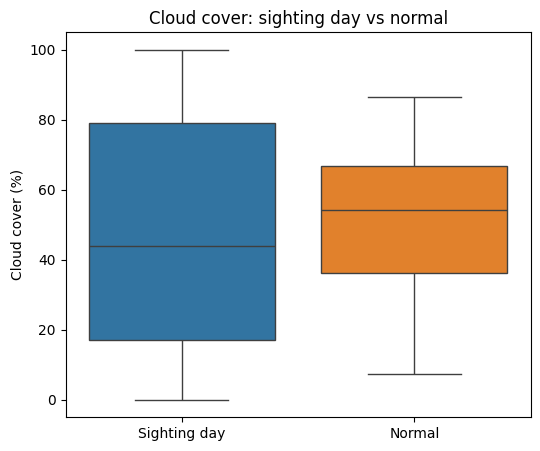

In [ ]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=data[["cloud_cover", "cloud_cover_avg"]])
plt.xticks([0, 1], ["Sighting day", "Normal"])
plt.title("Cloud cover: sighting day vs normal")
plt.xlabel("")
plt.ylabel("Cloud cover (%)")
plt.savefig("plot3_box.png", dpi=150)
plt.show()

**Plot 4. Bar: average cloud cover by decade**

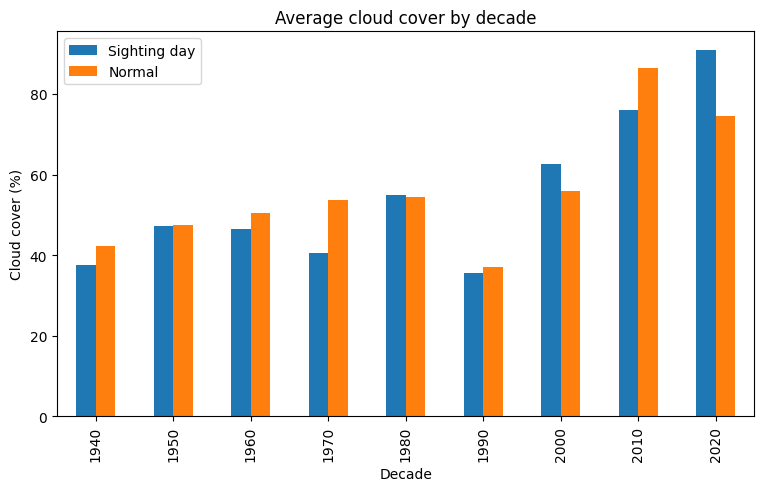

In [ ]:
by_decade = data.groupby("decade")[["cloud_cover", "cloud_cover_avg"]].mean()

by_decade.plot(kind="bar", figsize=(9, 5))
plt.legend(["Sighting day", "Normal"])
plt.title("Average cloud cover by decade")
plt.xlabel("Decade")
plt.ylabel("Cloud cover (%)")
plt.savefig("plot4_bar.png", dpi=150)
plt.show()

**Conclusions**

1. Weather was found for 58 of 137 events, so the sample is small.
2. Average cloud cover on the sighting day is 44.9%, and the normal value for the same place and season is 49.6%. The sighting day is slightly less cloudy, not more.
3. The p-value of the paired t-test is 0.196 (Wilcoxon: 0.226). The difference is not significant, so the data does not show that UFOs appear only when it is cloudy.
4. The share of cloudy days (50% or more) is 45%, and only 43% of events were cloudier than normal. About 36% of the sighting days had precipitation.
5. The events are famous cases from Wikipedia, not all sightings, so the result cannot be generalized.